# **5. Benchmarks de Segmentación**

En esta fase se implementan y evalúan cinco arquitecturas representativas de segmentación semántica sobre el subconjunto de segmentación de BRISC 2025. El objetivo es establecer líneas base robustas y comparables bajo condiciones experimentales estandarizadas: mismas particiones de datos, mismo preprocesamiento base, misma función de pérdida, mismo optimizador y una política homogénea de entrenamiento.

Las arquitecturas seleccionadas cubren distintas familias de modelos ampliamente utilizadas en segmentación médica:

| Modelo | Familia | Motivación |
|---|---|---|
| U-Net | CNN encoder–decoder | Baseline clásico en segmentación biomédica |
| Attention U-Net | CNN + atención | Refuerza regiones relevantes en skip connections |
| TransUNet | CNN + Transformer | Integra contexto global mediante self-attention |
| UNet++ | CNN con skip connections densas | Mejora la fusión multi-escala |
| DeepLabV3+ | CNN + convoluciones dilatadas | Captura contexto multi-escala con ASPP |

Todos los modelos se entrenan sobre imágenes preprocesadas a $512 \times 512$, en escala de grises, con máscaras binarias, utilizando augmentación moderada exclusivamente en entrenamiento. Dado que el entrenamiento se ejecutará sobre GPU NVIDIA A100 en Colab, la configuración se ajusta para aprovechar mixed precision, paralelismo de carga y una política de entrenamiento más rápida y estable.

---

## 5.1 Configuración del Entorno e Importación de Librerías


In [1]:
# ============================================================
# 1. CONFIGURACIÓN DEL ENTORNO
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q segmentation-models-pytorch==0.5.0
!pip install -q albumentations==1.4.0

import os
import gc
import re
import time
import copy
import json
import math
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from collections import defaultdict

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("=" * 70)
print("CONFIGURACIÓN DEL ENTORNO — BENCHMARKS")
print("=" * 70)
print(f"PyTorch:     {torch.__version__}")
print(f"SMP:         {smp.__version__}")
print(f"Device:      {device}")
if torch.cuda.is_available():
    print(f"GPU:         {torch.cuda.get_device_name(0)}")
    print(f"VRAM total:  {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"Seed:        {SEED}")
print("=" * 70)


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 8.6 MB/s eta 0:00:00
CONFIGURACIÓN DEL ENTORNO — BENCHMARKS
PyTorch:     2.10.0+cu128
SMP:         0.5.0
Device:      cuda
GPU:         NVIDIA A100-SXM4-80GB
VRAM total:  79.3 GB
Seed:        42



## 5.2 Carga de Datos y DataLoaders

Se reutilizan los splits estratificados generados en la fase de preprocesamiento. De este modo, todos los modelos se entrenan y evalúan sobre exactamente las mismas particiones, garantizando comparabilidad justa entre arquitecturas.

La configuración de carga de datos se ajusta para GPU A100, priorizando rendimiento y estabilidad:

- `IMG_SIZE = 512`
- `BATCH_SIZE = 24`
- `NUM_WORKERS = 8`
- `pin_memory = True` cuando hay GPU
- `persistent_workers = True` para evitar reinicio de workers en cada época



In [2]:
# ============================================================
# 2. CARGA DE DATOS Y DATALOADERS
# ============================================================

# ── Rutas ────────────────────────────────────────────────────
DRIVE_ROOT   = "/content/drive/MyDrive/tumores_ceb_proyecto"
SPLITS_DIR   = os.path.join(DRIVE_ROOT, "splits")
CKPT_DIR     = os.path.join(DRIVE_ROOT, "checkpoints_benchmark")
RESULTS_DIR  = os.path.join(DRIVE_ROOT, "results_benchmark")
FIGURES_DIR  = os.path.join(DRIVE_ROOT, "figures_benchmark")
COLAB_DATA   = "/content/brisc2025"
ZIP_PATH     = os.path.join(DRIVE_ROOT, "brisc2025.zip")

for d in [CKPT_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Descomprimir dataset si no está disponible ───────────────
if not os.path.exists(COLAB_DATA):
    print("Descomprimiendo dataset...")
    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall("/content/")
    print(f"Completado en {(time.time()-t0)/60:.2f} min")
else:
    print(f"Dataset disponible en {COLAB_DATA}")

# ── Constantes ───────────────────────────────────────────────
IMG_SIZE    = 512
BATCH_SIZE = 64
NUM_WORKERS = 8 if torch.cuda.is_available() else 4
PIN_MEMORY  = torch.cuda.is_available()

PLANE_TO_IDX = {'Axial': 0, 'Coronal': 1, 'Sagittal': 2}

# ── Cargar splits desde Drive ────────────────────────────────
df_train = pd.read_csv(os.path.join(SPLITS_DIR, 'split_train.csv'))
df_val   = pd.read_csv(os.path.join(SPLITS_DIR, 'split_val.csv'))
df_test  = pd.read_csv(os.path.join(SPLITS_DIR, 'split_test.csv'))

print("\nSplits cargados:")
print(f"  Train: {len(df_train)}")
print(f"  Val:   {len(df_val)}")
print(f"  Test:  {len(df_test)}")

# ── Dataset ──────────────────────────────────────────────────
class BRISCSegDataset(Dataset):
    def __init__(self, dataframe, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = np.array(
            Image.open(row['image_path']).convert('L'),
            dtype=np.float32
        ) / 255.0

        mask = np.array(
            Image.open(row['mask_path']).convert('L'),
            dtype=np.float32
        ) / 255.0
        mask = (mask > 0.5).astype(np.float32)

        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed['image']
            mask  = transformed['mask']
        else:
            image = torch.from_numpy(image).float()
            mask  = torch.from_numpy(mask).float()

        image = image.float().clamp(0.0, 1.0)
        mask  = (mask > 0.5).float()

        if image.ndim == 2:
            image = image.unsqueeze(0)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        meta = {
            'filename': row['filename'],
            'tumor_label': row['tumor_label'],
            'plane_label': row['plane_label'],
            'plane_idx': torch.tensor(
                PLANE_TO_IDX.get(row['plane_label'], 0),
                dtype=torch.long
            ),
        }
        return image, mask, meta

# ── Transforms ───────────────────────────────────────────────
train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=2),  # BICUBIC
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.05,
        rotate_limit=10,
        border_mode=0,
        p=0.30
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.10,
        p=0.25
    ),
    A.GaussNoise(var_limit=(3.0, 12.0), p=0.15),
    ToTensorV2(),
])

val_test_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=2),  # BICUBIC
    ToTensorV2(),
])

print("\nTransforms definidos:")
print(f"  Train:    Resize({IMG_SIZE}) + augmentación moderada + ToTensor")
print(f"  Val/Test: Resize({IMG_SIZE}) + ToTensor")
print("  Interpolación imagen: BICUBIC (2)")
print("  Política de máscara: re-binarización post-transform")

# ── Datasets y DataLoaders ───────────────────────────────────
train_dataset = BRISCSegDataset(df_train, transforms=train_transforms)
val_dataset   = BRISCSegDataset(df_val,   transforms=val_test_transforms)
test_dataset  = BRISCSegDataset(df_test,  transforms=val_test_transforms)

_dl_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=(NUM_WORKERS > 0),
)

if NUM_WORKERS > 0:
    _dl_kwargs["prefetch_factor"] = 4

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    drop_last=True,
    **_dl_kwargs
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    drop_last=False,
    **_dl_kwargs
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    drop_last=False,
    **_dl_kwargs
)

print("\nDatasets y DataLoaders creados:")
print(f"\n{'Dataset':<15} {'Samples':>8} {'Batches':>8} {'Transforms':>24}")
print("─" * 62)
print(f"{'Train':<15} {len(train_dataset):>8} {len(train_loader):>8} {'Augmentación moderada':>24}")
print(f"{'Validation':<15} {len(val_dataset):>8} {len(val_loader):>8} {'Preproc only':>24}")
print(f"{'Test':<15} {len(test_dataset):>8} {len(test_loader):>8} {'Preproc only':>24}")

print("\nConfiguración de carga:")
print(f"  Num workers:         {NUM_WORKERS}")
print(f"  Pin memory:          {PIN_MEMORY}")
print(f"  Persistent workers:  {_dl_kwargs['persistent_workers']}")
print(f"  Prefetch factor:     {_dl_kwargs.get('prefetch_factor', 'N/A')}")


Descomprimiendo dataset...
Completado en 0.08 min

Splits cargados:
  Train: 3146
  Val:   787
  Test:  860

Transforms definidos:
  Train:    Resize(512) + augmentación moderada + ToTensor
  Val/Test: Resize(512) + ToTensor
  Interpolación imagen: BICUBIC (2)
  Política de máscara: re-binarización post-transform

Datasets y DataLoaders creados:

Dataset          Samples  Batches               Transforms
──────────────────────────────────────────────────────────────
Train               3146       49    Augmentación moderada
Validation           787       13             Preproc only
Test                 860       14             Preproc only

Configuración de carga:
  Num workers:         8
  Pin memory:          True
  Persistent workers:  True
  Prefetch factor:     4


## 5.3 Verificación Rápida del Pipeline

Antes de entrenar, se verifica que los `DataLoaders` entreguen tensores con forma, tipo y rango correctos.


In [3]:
# ============================================================
# 3. VERIFICACIÓN DEL PIPELINE
# ============================================================

def verify_batch(loader, name):
    images, masks, metas = next(iter(loader))

    print(f"\n{'='*60}")
    print(f"Verificación: {name}")
    print(f"{'='*60}")
    print(f"Images shape:  {images.shape}")
    print(f"Images dtype:  {images.dtype}")
    print(f"Images range:  [{images.min():.4f}, {images.max():.4f}]")
    print(f"Masks shape:   {masks.shape}")
    print(f"Masks dtype:   {masks.dtype}")
    print(f"Masks unique:  {torch.unique(masks).tolist()}")
    print(f"Masks range:   [{masks.min():.4f}, {masks.max():.4f}]")
    print(f"Meta keys:     {list(metas.keys())}")
    print(f"Tumor labels:  {list(metas['tumor_label'][:4])}")
    print(f"Plane labels:  {list(metas['plane_label'][:4])}")
    print(f"Plane idx:     {metas['plane_idx'][:4].tolist()}")

    checks = {
        'Shape (B, 1, H, W)': images.shape[1:] == (1, IMG_SIZE, IMG_SIZE),
        'Float32': images.dtype == torch.float32,
        'Range [0,1]': images.min() >= 0.0 and images.max() <= 1.0,
        'Mask binary': set(torch.unique(masks).tolist()).issubset({0.0, 1.0}),
        'Mask shape match': masks.shape == images.shape,
        'plane_idx en meta': 'plane_idx' in metas,
        'plane_idx dtype long': metas['plane_idx'].dtype == torch.long,
    }

    print("\nValidaciones:")
    all_ok = True
    for check_name, passed in checks.items():
        status = 'Correcto' if passed else 'ERROR'
        print(f"  {status:<10} {check_name}")
        if not passed:
            all_ok = False

    return all_ok

ok_train = verify_batch(train_loader, "Train DataLoader")
ok_val   = verify_batch(val_loader, "Validation DataLoader")
ok_test  = verify_batch(test_loader, "Test DataLoader")

print(f"\n{'='*60}")
if ok_train and ok_val and ok_test:
    print("TODOS LOS DATALOADERS VERIFICADOS CORRECTAMENTE")
else:
    print("SE DETECTARON PROBLEMAS — REVISAR ARRIBA")
print(f"{'='*60}")



Verificación: Train DataLoader
Images shape:  torch.Size([64, 1, 512, 512])
Images dtype:  torch.float32
Images range:  [0.0000, 1.0000]
Masks shape:   torch.Size([64, 1, 512, 512])
Masks dtype:   torch.float32
Masks unique:  [0.0, 1.0]
Masks range:   [0.0000, 1.0000]
Meta keys:     ['filename', 'tumor_label', 'plane_label', 'plane_idx']
Tumor labels:  ['Pituitary', 'Glioma', 'Pituitary', 'Pituitary']
Plane labels:  ['Coronal', 'Axial', 'Sagittal', 'Axial']
Plane idx:     [1, 0, 2, 0]

Validaciones:
  Correcto   Shape (B, 1, H, W)
  Correcto   Float32
  Correcto   Range [0,1]
  Correcto   Mask binary
  Correcto   Mask shape match
  Correcto   plane_idx en meta
  Correcto   plane_idx dtype long

Verificación: Validation DataLoader
Images shape:  torch.Size([64, 1, 512, 512])
Images dtype:  torch.float32
Images range:  [0.0000, 1.0000]
Masks shape:   torch.Size([64, 1, 512, 512])
Masks dtype:   torch.float32
Masks unique:  [0.0, 1.0]
Masks range:   [0.0000, 1.0000]
Meta keys:     ['file

## 5.4 Funciones de Pérdida y Métricas de Evaluación

Dado el desbalance extremo entre píxeles de tumor y fondo, se utiliza una pérdida combinada Dice + BCE. Como métricas principales se reportan IoU y Dice Score.


In [4]:
# ============================================================
# 4. FUNCIONES DE PÉRDIDA Y MÉTRICAS
# ============================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred_flat = pred.reshape(-1)
        target_flat = target.reshape(-1)
        intersection = (pred_flat * target_flat).sum()

        dice = (2.0 * intersection + self.smooth) / (
            pred_flat.sum() + target_flat.sum() + self.smooth
        )
        return 1.0 - dice


class ComboLoss(nn.Module):
    def __init__(self, alpha=0.5, smooth=1.0):
        super().__init__()
        self.alpha = alpha
        self.dice_loss = DiceLoss(smooth=smooth)
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        return (
            self.alpha * self.dice_loss(pred, target)
            + (1 - self.alpha) * self.bce_loss(pred, target)
        )


def compute_iou(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    union = pred_bin.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - intersection
    return (intersection + smooth) / (union + smooth)


def compute_dice(pred, target, threshold=0.5, smooth=1e-6):
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    return (2.0 * intersection + smooth) / (
        pred_bin.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + smooth
    )


print("Funciones de pérdida y métricas definidas.")
print("  Loss:    ComboLoss (0.5 · Dice + 0.5 · BCE)")
print("  Metrics: IoU, Dice Score")


Funciones de pérdida y métricas definidas.
  Loss:    ComboLoss (0.5 · Dice + 0.5 · BCE)
  Metrics: IoU, Dice Score


## 5.5 Motor de Entrenamiento Genérico

El entrenamiento se configura para un máximo de 200 épocas. Se incorpora:

- `AdamW`
- `ReduceLROnPlateau`
- `Mixed Precision (AMP)`
- `Early Stopping`
- `Checkpointing`

La paciencia se ajusta a una corrida de 200 épocas:

- `patience = 25`
- `scheduler_patience = 8`


In [5]:
# ============================================================
# 5. MOTOR DE ENTRENAMIENTO GENÉRICO
# ============================================================

HPARAMS = {
    'max_epochs': 500,
    'patience': 80,
    'learning_rate': 2e-4,
    'weight_decay': 1e-4,
    'scheduler_patience': 20,
    'scheduler_factor': 0.5,
    'min_lr': 1e-7,
    'grad_clip': 1.0,
}




print("Hiperparámetros compartidos:")
for k, v in HPARAMS.items():
    print(f"  {k}: {v}")

AMP_ENABLED = torch.cuda.is_available()
AMP_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def train_one_epoch(model, loader, criterion, optimizer, scaler, device, grad_clip=1.0):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    n_batches = 0

    for images, masks, _ in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()

        if grad_clip is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            running_loss += loss.item()
            running_iou += compute_iou(outputs, masks).mean().item()
            running_dice += compute_dice(outputs, masks).mean().item()
            n_batches += 1

    return {
        'loss': running_loss / n_batches,
        'iou': running_iou / n_batches,
        'dice': running_dice / n_batches,
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    n_batches = 0

    for images, masks, _ in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images)
            loss = criterion(outputs, masks)

        running_loss += loss.item()
        running_iou += compute_iou(outputs, masks).mean().item()
        running_dice += compute_dice(outputs, masks).mean().item()
        n_batches += 1

    return {
        'loss': running_loss / n_batches,
        'iou': running_iou / n_batches,
        'dice': running_dice / n_batches,
    }


def train_model(model, model_name, train_loader, val_loader, device, hparams=HPARAMS):
    print(f"\n{'='*70}")
    print(f"ENTRENAMIENTO: {model_name}")
    print(f"{'='*70}")

    total_p = sum(p.numel() for p in model.parameters())
    trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parámetros totales:      {total_p:,}")
    print(f"Parámetros entrenables:  {trainable_p:,}")
    print(f"Tamaño estimado:         {total_p*4/1024**2:.1f} MB")

    model = model.to(device)
    criterion = ComboLoss(alpha=0.5)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=hparams['learning_rate'],
        weight_decay=hparams['weight_decay']
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=hparams['scheduler_factor'],
        patience=hparams['scheduler_patience'],
        min_lr=hparams['min_lr']
    )

    scaler = GradScaler(device='cuda', enabled=AMP_ENABLED)

    history = {
        'train_loss': [],
        'train_iou': [],
        'train_dice': [],
        'val_loss': [],
        'val_iou': [],
        'val_dice': [],
        'lr': [],
    }

    best_val_dice = -1.0
    best_model_state = None
    best_epoch = 0
    patience_counter = 0
    start_time = time.time()

    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')

    for epoch in range(1, hparams['max_epochs'] + 1):
        epoch_start = time.time()

        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device,
            grad_clip=hparams['grad_clip']
        )
        val_metrics = evaluate(model, val_loader, criterion, device)

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_metrics['dice'])

        history['train_loss'].append(train_metrics['loss'])
        history['train_iou'].append(train_metrics['iou'])
        history['train_dice'].append(train_metrics['dice'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])
        history['lr'].append(current_lr)

        improved = val_metrics['dice'] > best_val_dice

        if improved:
            best_val_dice = val_metrics['dice']
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
            marker = "BEST"

            torch.save({
                'epoch': epoch,
                'model_state_dict': best_model_state,
                'val_dice': best_val_dice,
                'val_iou': val_metrics['iou'],
                'history_length': len(history['train_loss']),
                'hparams': hparams,
            }, ckpt_path)
        else:
            patience_counter += 1
            marker = f"patience {patience_counter}/{hparams['patience']}"

        print(
            f"Epoch {epoch:03d}/{hparams['max_epochs']} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Train IoU: {train_metrics['iou']:.4f} | "
            f"Train Dice: {train_metrics['dice']:.4f} || "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val IoU: {val_metrics['iou']:.4f} | "
            f"Val Dice: {val_metrics['dice']:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"{time.time()-epoch_start:.1f}s | {marker}"
        )

        if patience_counter >= hparams['patience']:
            print(f"\nEarly Stopping activado en epoch {epoch}.")
            print(f"Mejor epoch: {best_epoch} | Mejor Val Dice: {best_val_dice:.4f}")
            break

    model.load_state_dict(best_model_state)

    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')
    history_path = os.path.join(RESULTS_DIR, f'{safe_name}_history.json')

    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)

    total_time = time.time() - start_time

    print(f"\nResumen de entrenamiento — {model_name}")
    print("─" * 60)
    print(f"Mejor epoch:     {best_epoch}")
    print(f"Mejor Val Dice:  {best_val_dice:.4f}")
    print(f"Mejor Val IoU:   {history['val_iou'][best_epoch-1]:.4f}")
    print(f"Tiempo total:    {total_time/60:.1f} min")
    print(f"Checkpoint:      {ckpt_path}")
    print(f"Historial:       {history_path}")

    return model, history


print("\nMotor de entrenamiento definido.")


Hiperparámetros compartidos:
  max_epochs: 500
  patience: 80
  learning_rate: 0.0002
  weight_decay: 0.0001
  scheduler_patience: 20
  scheduler_factor: 0.5
  min_lr: 1e-07
  grad_clip: 1.0

Motor de entrenamiento definido.


## 5.6 Evaluación Detallada en Test

Además de las métricas globales, se calcula rendimiento:

- global
- ponderado por clase (`weighted mIoU`)
- por tipo tumoral
- por plano anatómico
- por combinación tumor × plano


In [6]:
# ============================================================
# 6. EVALUACIÓN DETALLADA EN TEST
# ============================================================

@torch.no_grad()
def evaluate_detailed(model, loader, device, model_name="Model"):
    model.eval()
    all_results = []

    for images, masks, metas in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images)

        ious = compute_iou(outputs, masks)
        dices = compute_dice(outputs, masks)

        for i in range(len(images)):
            all_results.append({
                'filename': metas['filename'][i],
                'tumor_label': metas['tumor_label'][i],
                'plane_label': metas['plane_label'][i],
                'iou': ious[i].item(),
                'dice': dices[i].item(),
            })

    results_df = pd.DataFrame(all_results)

    tumor_iou = results_df.groupby('tumor_label')['iou'].mean()
    tumor_counts = results_df.groupby('tumor_label')['iou'].count()
    total_samples = tumor_counts.sum()
    weighted_miou = (tumor_iou * tumor_counts / total_samples).sum()

    plane_iou = results_df.groupby('plane_label')['iou'].mean()
    cross_iou = results_df.groupby(['tumor_label', 'plane_label'])['iou'].mean()

    global_iou = results_df['iou'].mean()
    global_dice = results_df['dice'].mean()

    summary = {
        'model_name': model_name,
        'global_iou': global_iou,
        'global_dice': global_dice,
        'weighted_miou': weighted_miou,
        'tumor_iou': tumor_iou.to_dict(),
        'plane_iou': plane_iou.to_dict(),
        'cross_iou': cross_iou.to_dict(),
        'tumor_dice': results_df.groupby('tumor_label')['dice'].mean().to_dict(),
        'plane_dice': results_df.groupby('plane_label')['dice'].mean().to_dict(),
    }

    print(f"\n{'='*70}")
    print(f"RESULTADOS EN TEST — {model_name}")
    print(f"{'='*70}")
    print(f"Weighted mIoU:  {weighted_miou*100:.2f}%")
    print(f"Global mIoU:    {global_iou*100:.2f}%")
    print(f"Global Dice:    {global_dice*100:.2f}%")

    print("\nmIoU por Tipo Tumoral:")
    for t in ['Glioma', 'Meningioma', 'Pituitary']:
        print(f"  {t:<15} {tumor_iou.get(t, 0)*100:.2f}%")

    print("\nmIoU por Plano Anatómico:")
    for p in ['Axial', 'Coronal', 'Sagittal']:
        print(f"  {p:<15} {plane_iou.get(p, 0)*100:.2f}%")

    print("\nmIoU por Tumor × Plano:")
    cross_table = results_df.pivot_table(
        values='iou',
        index='tumor_label',
        columns='plane_label',
        aggfunc='mean'
    ).reindex(
        index=['Glioma', 'Meningioma', 'Pituitary'],
        columns=['Axial', 'Coronal', 'Sagittal']
    ) * 100
    print(cross_table.round(2).to_string())

    return results_df, summary


def save_model_results(model_name, model, history, test_loader, device):
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')

    results_df, summary = evaluate_detailed(
        model=model,
        loader=test_loader,
        device=device,
        model_name=model_name
    )

    results_df.to_csv(
        os.path.join(RESULTS_DIR, f'{safe_name}_test_results.csv'),
        index=False
    )

    summary_serializable = {}
    for k, v in summary.items():
        if isinstance(v, dict):
            summary_serializable[k] = {str(kk): vv for kk, vv in v.items()}
        else:
            summary_serializable[k] = v

    with open(os.path.join(RESULTS_DIR, f'{safe_name}_summary.json'), 'w') as f:
        json.dump(summary_serializable, f, indent=2)

    print(f"\nResultados de {model_name} guardados en Drive")
    print(f"  • {safe_name}_test_results.csv ({len(results_df)} imágenes)")
    print(f"  • {safe_name}_summary.json")

    return results_df, summary


def model_already_trained(model_name):
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')

    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')
    summary_path = os.path.join(RESULTS_DIR, f'{safe_name}_summary.json')
    history_path = os.path.join(RESULTS_DIR, f'{safe_name}_history.json')

    exists = all(os.path.exists(p) for p in [ckpt_path, summary_path, history_path])

    if exists:
        ck = torch.load(ckpt_path, map_location='cpu')
        print(f"  {model_name} encontrado — Val Dice: {ck['val_dice']:.4f} (epoch {ck['epoch']})")

    return exists


def load_model_from_checkpoint(build_fn, model_name, device):
    model = build_fn()
    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')
    ck = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ck['model_state_dict'])
    model = model.to(device).eval()
    print(f"  {model_name} cargado desde checkpoint (Val Dice: {ck['val_dice']:.4f})")
    return model


def load_saved_results(model_name):
    safe_name = model_name.lower().replace(' ', '_').replace('+', 'plus')

    with open(os.path.join(RESULTS_DIR, f'{safe_name}_history.json'), 'r') as f:
        history = json.load(f)

    with open(os.path.join(RESULTS_DIR, f'{safe_name}_summary.json'), 'r') as f:
        summary = json.load(f)

    results_df = pd.read_csv(
        os.path.join(RESULTS_DIR, f'{safe_name}_test_results.csv')
    )

    print(f"  Resultados cargados: {len(results_df)} imágenes, {len(history['train_loss'])} epochs")
    return history, summary, results_df


print("Funciones auxiliares de evaluación definidas.")


Funciones auxiliares de evaluación definidas.


## 5.7 Funciones de Visualización

In [7]:
# ============================================================
# 7. FUNCIONES DE VISUALIZACIÓN
# ============================================================

def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    for ax, tr, vl, lbl in zip(
        axes,
        ['train_loss', 'train_iou', 'train_dice'],
        ['val_loss',   'val_iou',   'val_dice'],
        ['Loss', 'IoU', 'Dice Score']
    ):
        ax.plot(epochs, history[tr], label='Train', linewidth=1.8)
        ax.plot(epochs, history[vl], label='Validation', linewidth=1.8)
        ax.set_title(f'{model_name} — {lbl}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(lbl)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Curvas de Entrenamiento — {model_name}', fontsize=14, y=1.02)
    plt.tight_layout()

    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(
        os.path.join(FIGURES_DIR, f'benchmark_{safe}_curves.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


@torch.no_grad()
def visualize_predictions(model, loader, device, model_name, n_samples=6):
    model.eval()
    images_list, masks_list, preds_list, metas_list = [], [], [], []

    for images, masks, metas in loader:
        images_gpu = images.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            outputs = model(images_gpu)

        preds = (torch.sigmoid(outputs) > 0.5).float().cpu()

        for i in range(len(images)):
            images_list.append(images[i])
            masks_list.append(masks[i])
            preds_list.append(preds[i])
            metas_list.append({
                'tumor_label': metas['tumor_label'][i],
                'plane_label': metas['plane_label'][i],
                'filename': metas['filename'][i],
            })

        if len(images_list) >= n_samples:
            break

    n_samples = min(n_samples, len(images_list))
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, n_samples * 3.5))

    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n_samples):
        img_np = np.clip(images_list[i][0].numpy(), 0, 1)
        gt_np = masks_list[i][0].numpy()
        pred_np = preds_list[i][0].numpy()
        meta = metas_list[i]

        overlay = np.stack([img_np, img_np, img_np], axis=-1)
        tp = (gt_np == 1) & (pred_np == 1)
        fn = (gt_np == 1) & (pred_np == 0)
        fp = (gt_np == 0) & (pred_np == 1)
        overlay[tp] = [0.0, 0.8, 0.0]
        overlay[fn] = [0.9, 0.0, 0.0]
        overlay[fp] = [0.0, 0.3, 0.9]

        intersection = tp.sum()
        union = (gt_np == 1).sum() + (pred_np == 1).sum() - intersection
        iou = intersection / (union + 1e-6)

        axes[i, 0].imshow(img_np, cmap='gray')
        axes[i, 0].set_title(f"{meta['tumor_label']}/{meta['plane_label']}", fontsize=9)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt_np, cmap='gray')
        axes[i, 1].set_title('Ground Truth', fontsize=9)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_np, cmap='gray')
        axes[i, 2].set_title('Predicción', fontsize=9)
        axes[i, 2].axis('off')

        axes[i, 3].imshow(np.clip(overlay, 0, 1))
        axes[i, 3].set_title(f'Overlay — IoU: {iou*100:.1f}%', fontsize=9)
        axes[i, 3].axis('off')

    for ax, t in zip(
        axes[0],
        ['Imagen MRI', 'Ground Truth', 'Predicción', 'Overlay (🟢TP 🔴FN 🔵FP)']
    ):
        ax.set_title(t, fontsize=10, fontweight='bold')

    fig.suptitle(f'Predicciones en Test — {model_name}', fontsize=14, y=1.01)
    plt.tight_layout()

    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(
        os.path.join(FIGURES_DIR, f'benchmark_{safe}_predictions.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


@torch.no_grad()
def visualize_best_worst(model, results_df, df_test_ref, device, model_name, n=5):
    model.eval()

    results_with_paths = results_df.merge(
        df_test_ref[['filename', 'image_path', 'mask_path']],
        on='filename',
        how='left'
    )

    best = results_with_paths.nlargest(n, 'iou')
    worst = results_with_paths.nsmallest(n, 'iou')

    fig, axes = plt.subplots(2, n, figsize=(n * 3.5, 7))

    for row_idx, (subset, label) in enumerate([(best, 'Mejores'), (worst, 'Peores')]):
        for col_idx, (_, sample) in enumerate(subset.iterrows()):
            img = np.array(Image.open(sample['image_path']).convert('L'), dtype=np.float32) / 255.0
            mask = np.array(Image.open(sample['mask_path']).convert('L'), dtype=np.float32) / 255.0
            mask = (mask > 0.5).astype(np.float32)

            transform = A.Compose([
                A.Resize(IMG_SIZE, IMG_SIZE, interpolation=2),
                ToTensorV2()
            ])
            result = transform(image=img, mask=mask)

            img_t = result['image'].clamp(0, 1).unsqueeze(0).to(device)

            with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                pred = (torch.sigmoid(model(img_t)) > 0.5).float().cpu().squeeze().numpy()

            img_np = np.clip(result['image'].squeeze().numpy(), 0, 1)
            gt_np = result['mask'].numpy()

            overlay = np.stack([img_np, img_np, img_np], axis=-1)
            tp = (gt_np == 1) & (pred == 1)
            fn = (gt_np == 1) & (pred == 0)
            fp = (gt_np == 0) & (pred == 1)

            overlay[tp] = [0.0, 0.8, 0.0]
            overlay[fn] = [0.9, 0.0, 0.0]
            overlay[fp] = [0.0, 0.3, 0.9]

            axes[row_idx, col_idx].imshow(np.clip(overlay, 0, 1))
            axes[row_idx, col_idx].set_title(
                f"{sample['tumor_label'][:3]}/{sample['plane_label'][:3]}\nIoU: {sample['iou']*100:.1f}%",
                fontsize=9
            )
            axes[row_idx, col_idx].axis('off')

    axes[0, 0].set_ylabel('Mejores', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Peores', fontsize=12, fontweight='bold')
    fig.suptitle(f'Top {n} Mejores y Peores — {model_name}', fontsize=14, y=1.02)
    plt.tight_layout()

    safe = model_name.lower().replace(' ', '_').replace('+', 'plus')
    plt.savefig(
        os.path.join(FIGURES_DIR, f'benchmark_{safe}_best_worst.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


print("Funciones de visualización definidas.")


Funciones de visualización definidas.


## 5.8 Definición de Arquitecturas

### 5.8.1 U-Net

In [8]:
# ============================================================
# 8.1 U-NET
# ============================================================

def build_unet():
    return smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None
    )

print("U-Net definido (encoder: ResNet34, pretrained: ImageNet)")


U-Net definido (encoder: ResNet34, pretrained: ImageNet)


### 5.8.2 Attention U-Net

In [9]:
# ============================================================
# 8.2 ATTENTION U-NET
# ============================================================

def build_attention_unet():
    return smp.Unet(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None,
        decoder_attention_type='scse'
    )

print("Attention U-Net definido (encoder: ResNet34, attention: scSE)")


Attention U-Net definido (encoder: ResNet34, attention: scSE)


### 5.8.3 TransUNet

In [10]:
# ============================================================
# 8.3 TRANSUNET (IMPLEMENTACIÓN PERSONALIZADA)
# ============================================================

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads=8, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=drop,
            batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(int(dim * mlp_ratio), dim),
            nn.Dropout(drop),
        )

    def forward(self, x):
        xn = self.norm1(x)
        a, _ = self.attn(xn, xn, xn)
        x = x + a
        x = x + self.ffn(self.norm2(x))
        return x


class TransUNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        num_classes=1,
        img_size=512,
        transformer_dim=256,
        num_heads=8,
        num_layers=4,
        drop=0.1
    ):
        super().__init__()
        self.img_size = img_size

        import torchvision.models as models
        resnet = models.resnet34(weights='IMAGENET1K_V1')

        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.conv1.weight.copy_(resnet.conv1.weight.mean(dim=1, keepdim=True))

        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3

        self.proj = nn.Conv2d(256, transformer_dim, kernel_size=1)

        self.transformer = nn.Sequential(*[
            TransformerBlock(
                dim=transformer_dim,
                num_heads=num_heads,
                mlp_ratio=4.0,
                drop=drop
            )
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(transformer_dim)

        self.up3 = nn.ConvTranspose2d(transformer_dim, 128, kernel_size=2, stride=2)
        self.dec3 = self._double_conv(128 + 128, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = self._double_conv(64 + 64, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = self._double_conv(32 + 64, 32)

        self.up0 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.final = nn.Conv2d(16, num_classes, kernel_size=1)

    def _double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))      # 1/2
        x_pool = self.maxpool(x0)                    # 1/4
        s1 = self.layer1(x_pool)                     # 1/4
        s2 = self.layer2(s1)                         # 1/8
        s3 = self.layer3(s2)                         # 1/16

        t = self.proj(s3)
        B, C, H, W = t.shape
        t = t.flatten(2).permute(0, 2, 1)
        t = self.transformer(t)
        t = self.norm(t)
        t = t.permute(0, 2, 1).reshape(B, C, H, W)

        d3 = self.up3(t)
        d3 = self.dec3(torch.cat([d3, s2], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, s1], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, x0], dim=1))

        d0 = self.up0(d1)
        return self.final(d0)


def build_transunet():
    return TransUNet(
        in_channels=1,
        num_classes=1,
        img_size=IMG_SIZE,
        transformer_dim=256,
        num_heads=8,
        num_layers=4,
        drop=0.1
    )

print("TransUNet definido (encoder: ResNet34 + 4 Transformer blocks)")


TransUNet definido (encoder: ResNet34 + 4 Transformer blocks)


### 5.8.4 UNet++

In [11]:
# ============================================================
# 8.4 UNET++
# ============================================================

def build_unetplusplus():
    return smp.UnetPlusPlus(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None
    )

print("UNet++ definido (encoder: ResNet34, pretrained: ImageNet)")


UNet++ definido (encoder: ResNet34, pretrained: ImageNet)


### 5.8.5 DeepLabV3+

In [12]:
# ============================================================
# 8.5 DEEPLABV3+
# ============================================================

def build_deeplabv3plus():
    return smp.DeepLabV3Plus(
        encoder_name='resnet34',
        encoder_weights='imagenet',
        in_channels=1,
        classes=1,
        activation=None
    )

print("DeepLabV3+ definido (encoder: ResNet34, pretrained: ImageNet)")


DeepLabV3+ definido (encoder: ResNet34, pretrained: ImageNet)


## 5.9 Inicialización del Benchmark

In [13]:
# ============================================================
# 9. INICIALIZACIÓN DEL BENCHMARK
# ============================================================

BENCHMARK_MODELS = [
    ('UNet', build_unet),
    ('AttentionUNet', build_attention_unet),
    ('TransUNet', build_transunet),
    ('UNetPlusPlus', build_unetplusplus),
    ('DeepLabV3Plus', build_deeplabv3plus),
]

all_summaries = {}
all_results = {}
all_histories = {}

print("Benchmark inicializado.")
print(f"Modelos: {[n for n, _ in BENCHMARK_MODELS]}")

print("\nVerificando modelos ya entrenados...\n")
for model_name, _ in BENCHMARK_MODELS:
    model_already_trained(model_name)


Benchmark inicializado.
Modelos: ['UNet', 'AttentionUNet', 'TransUNet', 'UNetPlusPlus', 'DeepLabV3Plus']

Verificando modelos ya entrenados...

  UNet encontrado — Val Dice: 0.8844 (epoch 109)
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)


## 5.10 Entrenamiento Secuencial de los Benchmarks

En esta subsección se define la lista oficial de arquitecturas del benchmark y se inicializan los contenedores donde se almacenarán historiales, resultados y resúmenes. Esta celda no entrena modelos; únicamente prepara el entorno para ejecutar cada arquitectura de forma independiente en celdas separadas.

In [14]:
# ============================================================
# 10. INICIALIZACIÓN DEL BENCHMARK
# ============================================================

BENCHMARK_MODELS = [
    ('UNet', build_unet),
    ('AttentionUNet', build_attention_unet),
    ('TransUNet', build_transunet),
    ('UNetPlusPlus', build_unetplusplus),
    ('DeepLabV3Plus', build_deeplabv3plus),
]

all_summaries = {}
all_results   = {}
all_histories = {}

print("Benchmark inicializado.")
print(f"Modelos: {[n for n, _ in BENCHMARK_MODELS]}")

print("\nVerificando modelos ya entrenados...\n")
for model_name, _ in BENCHMARK_MODELS:
    model_already_trained(model_name)



Benchmark inicializado.
Modelos: ['UNet', 'AttentionUNet', 'TransUNet', 'UNetPlusPlus', 'DeepLabV3Plus']

Verificando modelos ya entrenados...

  UNet encontrado — Val Dice: 0.8844 (epoch 109)
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)


## 5.11 Entrenamiento: U-Net

Esta celda entrena exclusivamente el modelo U-Net. Si el modelo ya fue entrenado previamente y existen sus archivos en disco, se cargan directamente los resultados sin repetir el entrenamiento.

  UNet encontrado — Val Dice: 0.8844 (epoch 109)

UNet ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 189 epochs


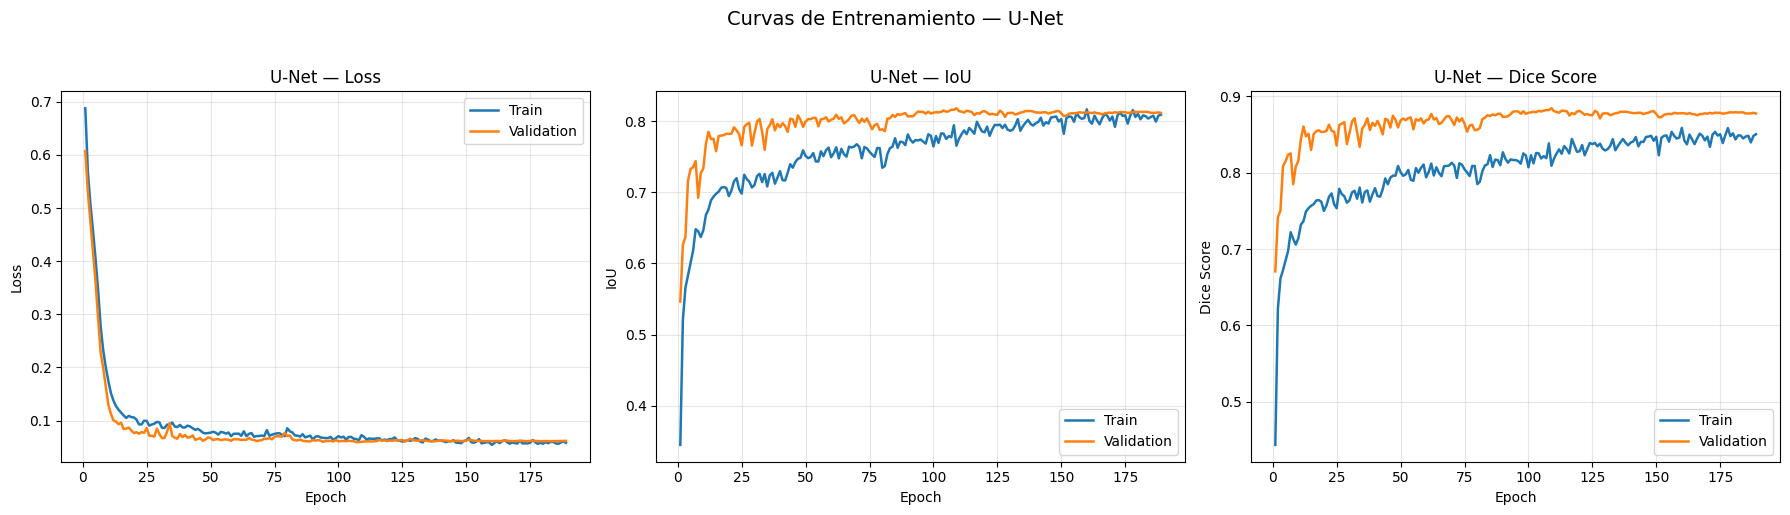


UNet completado y guardado.


In [15]:
# ============================================================
# 11. ENTRENAMIENTO: U-NET
# ============================================================

_name = 'UNet'
_build_fn = build_unet

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "U-Net")
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "U-Net")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="U-Net",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


## 5.12 Entrenamiento: Attention U-Net
Esta celda entrena exclusivamente Attention U-Net bajo la misma configuración experimental utilizada para el resto de arquitecturas.

  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)

AttentionUNet ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 201 epochs


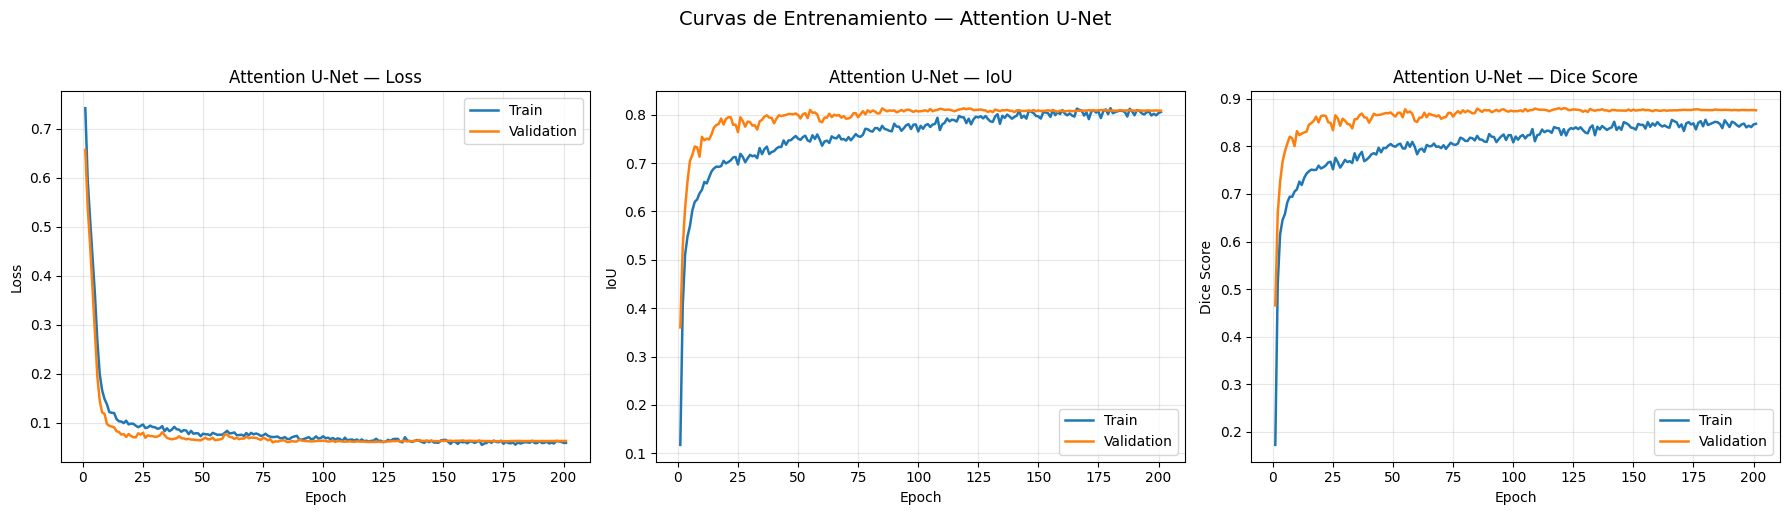


AttentionUNet completado y guardado.


In [16]:
# ============================================================
# 12. ENTRENAMIENTO: ATTENTION U-NET
# ============================================================

_name = 'AttentionUNet'
_build_fn = build_attention_unet

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "Attention U-Net")
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "Attention U-Net")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="Attention U-Net",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


## 5.13 Entrenamiento: TransUNet
Esta celda entrena exclusivamente TransUNet, arquitectura híbrida CNN–Transformer. Dado que suele ser el modelo más costoso computacionalmente, se ejecuta en una celda independiente para facilitar control del runtime y monitoreo de memoria.

  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)

TransUNet ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 220 epochs


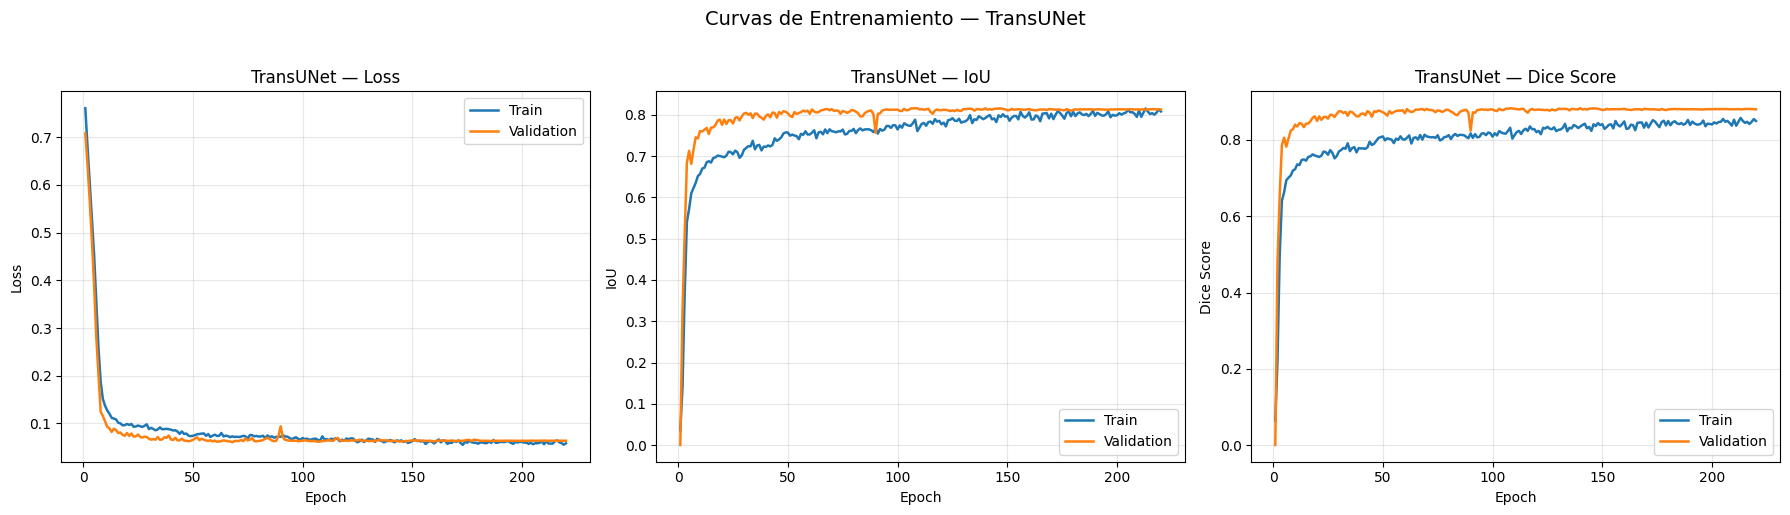


TransUNet completado y guardado.


In [17]:
# ============================================================
# 13. ENTRENAMIENTO: TRANSUNET
# ============================================================

_name = 'TransUNet'
_build_fn = build_transunet

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "TransUNet")
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "TransUNet")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="TransUNet",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


## 5.14 Entrenamiento: UNet++
Esta celda entrena exclusivamente UNet++, manteniendo la misma función de pérdida, optimizador y política de early stopping utilizada en el resto del benchmark.

  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)

UNetPlusPlus ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 160 epochs


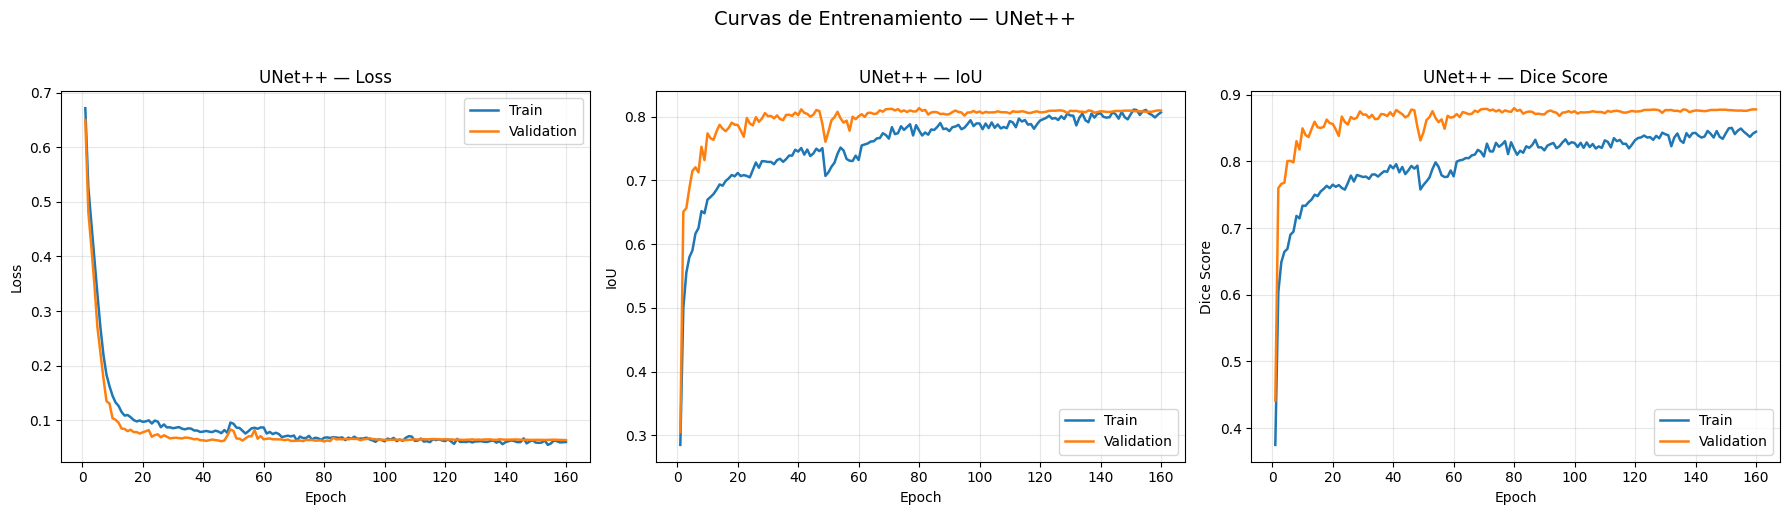


UNetPlusPlus completado y guardado.


In [18]:
# ============================================================
# 14. ENTRENAMIENTO: UNET++
# ============================================================

_name = 'UNetPlusPlus'
_build_fn = build_unetplusplus

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "UNet++")
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "UNet++")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="UNet++",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


## 5.15 Entrenamiento: DeepLabV3+
Esta celda entrena exclusivamente DeepLabV3+, completando así el conjunto de cinco arquitecturas benchmark.

  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)

DeepLabV3Plus ya entrenado. Cargando resultados desde disco...
  Resultados cargados: 860 imágenes, 229 epochs


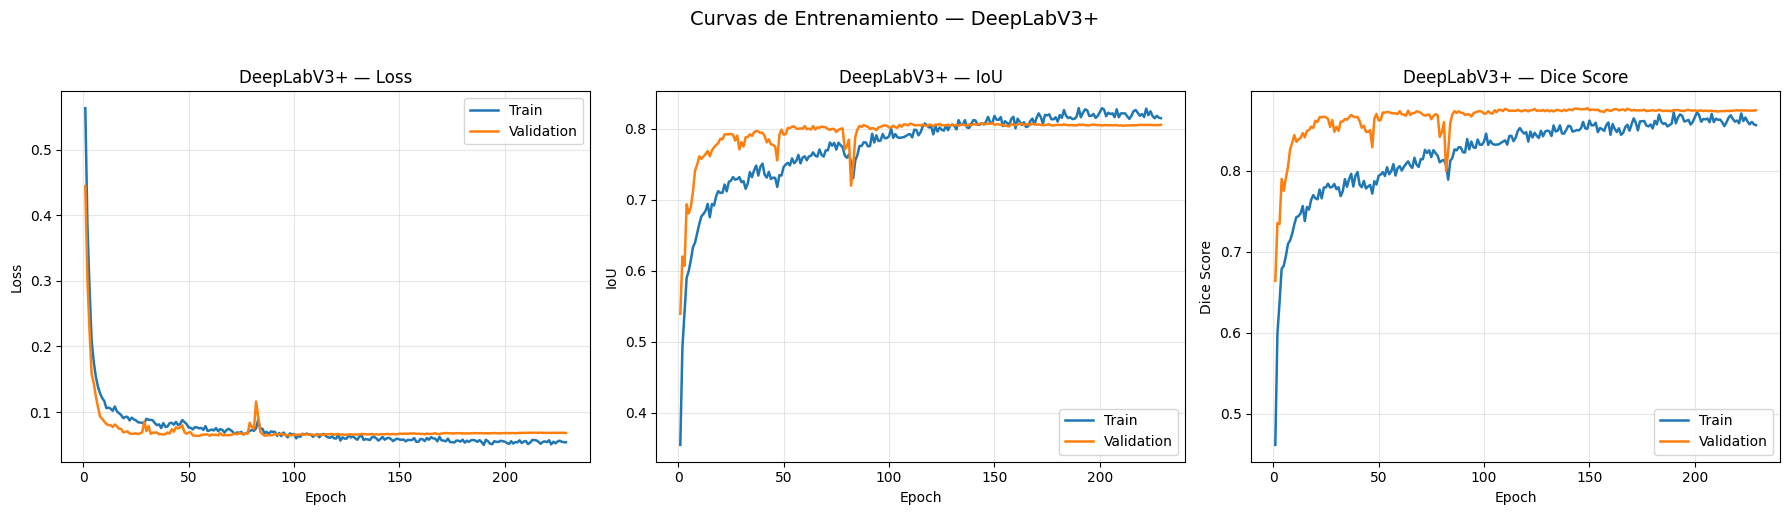


DeepLabV3Plus completado y guardado.


In [19]:
# ============================================================
# 15. ENTRENAMIENTO: DEEPLABV3+
# ============================================================

_name = 'DeepLabV3Plus'
_build_fn = build_deeplabv3plus

if model_already_trained(_name):
    print(f"\n{_name} ya entrenado. Cargando resultados desde disco...")
    _history, _summary, _results_df = load_saved_results(_name)
    plot_training_curves(_history, "DeepLabV3+")
else:
    clear_memory()
    _model = _build_fn()

    _model, _history = train_model(
        model=_model,
        model_name=_name,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        hparams=HPARAMS
    )

    plot_training_curves(_history, "DeepLabV3+")

    _results_df, _summary = save_model_results(
        model_name=_name,
        model=_model,
        history=_history,
        test_loader=test_loader,
        device=device
    )

    visualize_predictions(
        model=_model,
        loader=test_loader,
        device=device,
        model_name="DeepLabV3+",
        n_samples=6
    )

    del _model
    clear_memory()
    print(f"VRAM liberada después de {_name}")

all_histories[_name] = _history
all_summaries[_name] = _summary
all_results[_name]   = _results_df

print(f"\n{_name} completado y guardado.")


## 5.16 Verificación del Estado del Benchmark
Una vez entrenados uno o varios modelos, esta celda permite verificar qué arquitecturas ya cuentan con resultados completos guardados en disco y cuáles permanecen pendientes.

In [20]:
# ============================================================
# 16. VERIFICACIÓN DEL BENCHMARK
# ============================================================

print("=" * 70)
print("ESTADO DEL BENCHMARK")
print("=" * 70)

for model_name, _ in BENCHMARK_MODELS:
    trained = model_already_trained(model_name)
    in_memory = model_name in all_summaries
    status = "Completo" if trained else "Pendiente"
    print(f"{status} — {model_name}")

all_complete = all(model_already_trained(n) for n, _ in BENCHMARK_MODELS)

if all_complete:
    print("\nLos 5 modelos están entrenados. Listo para análisis.")
else:
    pending = [n for n, _ in BENCHMARK_MODELS if not model_already_trained(n)]
    print(f"\nModelos pendientes: {pending}")


ESTADO DEL BENCHMARK
  UNet encontrado — Val Dice: 0.8844 (epoch 109)
Completo — UNet
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
Completo — AttentionUNet
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
Completo — TransUNet
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
Completo — UNetPlusPlus
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)
Completo — DeepLabV3Plus
  UNet encontrado — Val Dice: 0.8844 (epoch 109)
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)

Los 5 modelos están entrenados. Listo para análisis.


## 5.17 Consolidación de Resultados y Visualización Best/Worst
Esta celda carga desde disco los resultados ya disponibles, consolida las salidas y permite inspeccionar los mejores y peores casos por modelo en el conjunto de test.

In [21]:
# ============================================================
# 17. CONSOLIDACIÓN DE RESULTADOS Y BEST/WORST
# ============================================================

if not all_summaries:
    print("Cargando resultados desde disco...\n")
    for model_name, build_fn in BENCHMARK_MODELS:
        if model_already_trained(model_name):
            _history, _summary, _results_df = load_saved_results(model_name)
            all_summaries[model_name] = _summary
            all_results[model_name]   = _results_df
            all_histories[model_name] = _history

print("=" * 70)
print("RESULTADOS CONSOLIDADOS EN TEST")
print("=" * 70)
print(f"Modelos evaluados: {list(all_summaries.keys())}")

for model_name, build_fn in BENCHMARK_MODELS:
    if model_name in all_results:
        print(f"\n{'─'*70}")
        print(f"Best/Worst — {model_name}")
        print(f"{'─'*70}")
        _model = load_model_from_checkpoint(build_fn, model_name, device)
        visualize_best_worst(
            model=_model,
            results_df=all_results[model_name],
            df_test_ref=df_test,
            device=device,
            model_name=model_name,
            n=5
        )
        del _model
        clear_memory()


Output hidden; open in https://colab.research.google.com to view.

## 5.18 Tabla Comparativa de Resultados
Esta subsección construye la tabla comparativa final entre los benchmarks propios y los valores reportados en el paper BRISC, además de resumir el rendimiento por plano anatómico y Dice Score global.

In [22]:
# ============================================================
# 18. TABLA COMPARATIVA DE RESULTADOS
# ============================================================

if not all_summaries:
    for model_name, _ in BENCHMARK_MODELS:
        if model_already_trained(model_name):
            _history, _summary, _results_df = load_saved_results(model_name)
            all_summaries[model_name] = _summary
            all_results[model_name]   = _results_df

brisc_benchmarks = [
    {'model':'UNet (BRISC)',        'glioma':69.7,'meningioma':77.1,'pituitary':79.3,'w_miou':75.7,'source':'Fateh et al.'},
    {'model':'UNet++ (BRISC)',      'glioma':71.7,'meningioma':74.2,'pituitary':79.7,'w_miou':75.3,'source':'Fateh et al.'},
    {'model':'MANet (BRISC)',       'glioma':72.4,'meningioma':77.5,'pituitary':78.0,'w_miou':76.2,'source':'Fateh et al.'},
    {'model':'LinkNet (BRISC)',     'glioma':71.7,'meningioma':74.8,'pituitary':79.0,'w_miou':75.3,'source':'Fateh et al.'},
    {'model':'DeepLabV3+ (BRISC)',  'glioma':72.0,'meningioma':77.5,'pituitary':78.7,'w_miou':76.3,'source':'Fateh et al.'},
    {'model':'PAN (BRISC)',         'glioma':72.0,'meningioma':74.5,'pituitary':80.7,'w_miou':75.9,'source':'Fateh et al.'},
    {'model':'EINet (BRISC)',       'glioma':73.6,'meningioma':78.4,'pituitary':80.3,'w_miou':77.7,'source':'Fateh et al.'},
    {'model':'EU-Net (BRISC)',      'glioma':71.7,'meningioma':76.1,'pituitary':78.3,'w_miou':75.6,'source':'Fateh et al.'},
    {'model':'DAD (BRISC)',         'glioma':75.2,'meningioma':80.4,'pituitary':82.3,'w_miou':79.5,'source':'Fateh et al.'},
    {'model':'BASNet (BRISC)',      'glioma':74.0,'meningioma':77.5,'pituitary':81.7,'w_miou':77.9,'source':'Fateh et al.'},
    {'model':'SaberNet (BRISC) ★',  'glioma':74.0,'meningioma':82.4,'pituitary':84.3,'w_miou':80.6,'source':'Fateh et al.'},
    {'model':'ABANet (BRISC)',      'glioma':72.4,'meningioma':80.4,'pituitary':84.7,'w_miou':79.5,'source':'Fateh et al.'},
]

our_benchmarks = []
for model_name, summary in all_summaries.items():
    t_iou  = summary['tumor_iou']
    w_miou = summary['weighted_miou']
    scale  = 100 if w_miou < 1 else 1

    our_benchmarks.append({
        'model':      f"{model_name} (Ours)",
        'glioma':     t_iou.get('Glioma', 0) * scale,
        'meningioma': t_iou.get('Meningioma', 0) * scale,
        'pituitary':  t_iou.get('Pituitary', 0) * scale,
        'w_miou':     w_miou * scale,
        'source':     'Ours',
    })

df_benchmark = (
    pd.DataFrame(brisc_benchmarks + our_benchmarks)
    .sort_values('w_miou', ascending=False)
    .reset_index(drop=True)
)

df_benchmark.to_csv(
    os.path.join(RESULTS_DIR, 'benchmark_results.csv'),
    index=False
)

print("\n" + "="*95)
print("TABLA COMPARATIVA — SEGMENTACIÓN EN BRISC 2025")
print("="*95)
print(f"\n{'Modelo':<30} {'Glioma':>8} {'Mening.':>8} {'Pituit.':>8} {'W-mIoU':>8} {'Fuente':>18}")
print("─"*95)

for _, row in df_benchmark.iterrows():
    marker = '★' if row['w_miou'] == df_benchmark['w_miou'].max() else ' '
    print(f"{marker} {row['model']:<28} {row['glioma']:>7.1f}% {row['meningioma']:>7.1f}% "
          f"{row['pituitary']:>7.1f}% {row['w_miou']:>7.1f}% {row['source']:>18}")

print("─"*95)

print("\n" + "="*75)
print("mIoU POR PLANO ANATÓMICO (Contribución Original)")
print("="*75)
print(f"\n{'Modelo':<25} {'Axial':>8} {'Coronal':>8} {'Sagittal':>10}")
print("─"*60)

for model_name, summary in all_summaries.items():
    p_iou = summary['plane_iou']
    sc = 100 if summary['weighted_miou'] < 1 else 1
    print(f"{model_name:<25} "
          f"{p_iou.get('Axial',0)*sc:>7.2f}% "
          f"{p_iou.get('Coronal',0)*sc:>7.2f}% "
          f"{p_iou.get('Sagittal',0)*sc:>9.2f}%")

print("─"*60)

print("\n" + "="*75)
print("DICE SCORE POR MODELO")
print("="*75)
print(f"\n{'Modelo':<25} {'Global':>8} {'Glioma':>8} {'Mening.':>8} {'Pituit.':>8}")
print("─"*65)

for model_name, summary in all_summaries.items():
    sc = 100 if summary['global_dice'] < 1 else 1
    t_dice = summary['tumor_dice']
    print(f"{model_name:<25} "
          f"{summary['global_dice']*sc:>7.2f}% "
          f"{t_dice.get('Glioma',0)*sc:>7.2f}% "
          f"{t_dice.get('Meningioma',0)*sc:>7.2f}% "
          f"{t_dice.get('Pituitary',0)*sc:>7.2f}%")

print("─"*65)



TABLA COMPARATIVA — SEGMENTACIÓN EN BRISC 2025

Modelo                           Glioma  Mening.  Pituit.   W-mIoU             Fuente
───────────────────────────────────────────────────────────────────────────────────────────────
★ UNet (Ours)                     68.7%    90.8%    81.3%    80.9%               Ours
  UNetPlusPlus (Ours)             68.6%    91.1%    80.7%    80.9%               Ours
  SaberNet (BRISC) ★              74.0%    82.4%    84.3%    80.6%       Fateh et al.
  AttentionUNet (Ours)            68.2%    90.9%    80.4%    80.5%               Ours
  DeepLabV3Plus (Ours)            68.4%    90.6%    80.2%    80.4%               Ours
  TransUNet (Ours)                67.6%    90.6%    80.6%    80.3%               Ours
  DAD (BRISC)                     75.2%    80.4%    82.3%    79.5%       Fateh et al.
  ABANet (BRISC)                  72.4%    80.4%    84.7%    79.5%       Fateh et al.
  BASNet (BRISC)                  74.0%    77.5%    81.7%    77.9%       Fateh et

## 5.19 Comparación Visual entre Modelos
Esta celda permite comparar visualmente, sobre un mismo subconjunto de muestras de test, las predicciones de todos los modelos ya entrenados.

  UNet encontrado — Val Dice: 0.8844 (epoch 109)
  UNet cargado desde checkpoint (Val Dice: 0.8844)
  AttentionUNet encontrado — Val Dice: 0.8802 (epoch 121)
  AttentionUNet cargado desde checkpoint (Val Dice: 0.8802)
  TransUNet encontrado — Val Dice: 0.8825 (epoch 140)
  TransUNet cargado desde checkpoint (Val Dice: 0.8825)
  UNetPlusPlus encontrado — Val Dice: 0.8798 (epoch 80)
  UNetPlusPlus cargado desde checkpoint (Val Dice: 0.8798)
  DeepLabV3Plus encontrado — Val Dice: 0.8771 (epoch 149)
  DeepLabV3Plus cargado desde checkpoint (Val Dice: 0.8771)


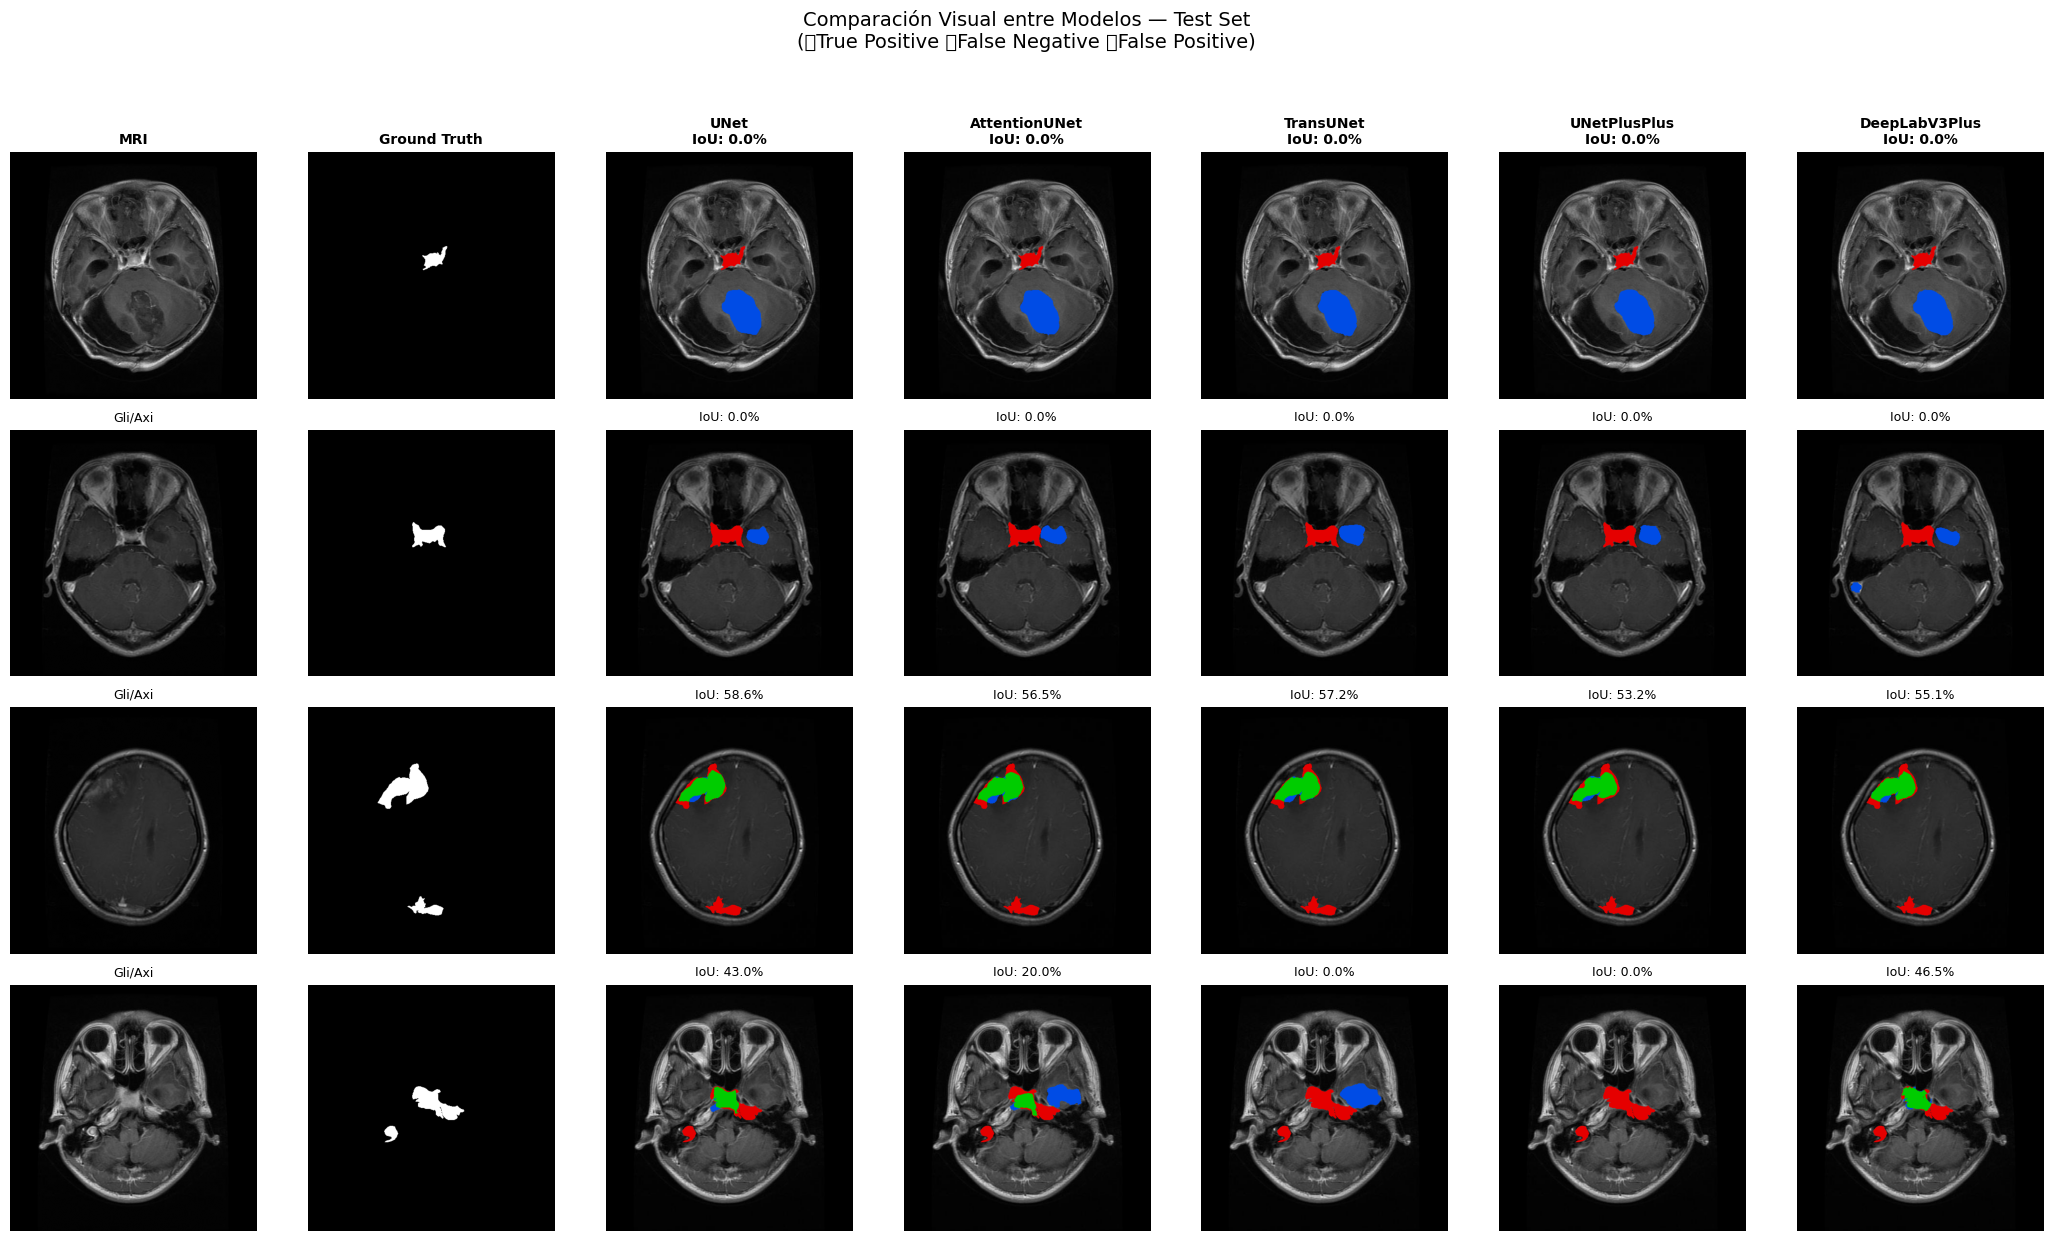

In [23]:
# ============================================================
# 19. COMPARACIÓN VISUAL ENTRE MODELOS
# ============================================================

@torch.no_grad()
def compare_models_visual(benchmark_models, loader, device, n_samples=4):
    images, masks, metas = next(iter(loader))
    n_models = len(benchmark_models)

    fig, axes = plt.subplots(
        n_samples,
        n_models + 2,
        figsize=((n_models + 2) * 3, n_samples * 3)
    )

    for i in range(n_samples):
        img_np = np.clip(images[i, 0].numpy(), 0, 1)
        gt_np  = masks[i, 0].numpy()

        axes[i, 0].imshow(img_np, cmap='gray')
        axes[i, 0].set_title(
            f"{metas['tumor_label'][i][:3]}/{metas['plane_label'][i][:3]}",
            fontsize=9
        )
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt_np, cmap='gray')
        if i == 0:
            axes[i, 1].set_title('Ground Truth', fontsize=10, fontweight='bold')
        axes[i, 1].axis('off')

    for j, (model_name, build_fn) in enumerate(benchmark_models):
        if not model_already_trained(model_name):
            continue

        _model = load_model_from_checkpoint(build_fn, model_name, device)

        for i in range(n_samples):
            img_np = np.clip(images[i, 0].numpy(), 0, 1)
            gt_np  = masks[i, 0].numpy()
            img_gpu = images[i:i+1].to(device)

            with autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                pred = (torch.sigmoid(_model(img_gpu)) > 0.5).float().cpu().squeeze().numpy()

            overlay = np.stack([img_np, img_np, img_np], axis=-1)
            tp = (gt_np == 1) & (pred == 1)
            fn = (gt_np == 1) & (pred == 0)
            fp = (gt_np == 0) & (pred == 1)

            overlay[tp] = [0.0, 0.8, 0.0]
            overlay[fn] = [0.9, 0.0, 0.0]
            overlay[fp] = [0.0, 0.3, 0.9]

            iou_val = tp.sum() / (tp.sum() + fn.sum() + fp.sum() + 1e-6)

            axes[i, j+2].imshow(np.clip(overlay, 0, 1))
            axes[i, j+2].set_title(f'IoU: {iou_val*100:.1f}%', fontsize=9)
            axes[i, j+2].axis('off')

            if i == 0:
                axes[0, j+2].set_title(
                    f'{model_name}\nIoU: {iou_val*100:.1f}%',
                    fontsize=10,
                    fontweight='bold'
                )

        del _model
        clear_memory()

    axes[0, 0].set_title('MRI', fontsize=10, fontweight='bold')
    fig.suptitle(
        'Comparación Visual entre Modelos — Test Set\n(🟢True Positive 🔴False Negative 🔵False Positive)',
        fontsize=14,
        y=1.03
    )
    plt.tight_layout()
    plt.savefig(
        os.path.join(FIGURES_DIR, 'benchmark_model_comparison.png'),
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


compare_models_visual(BENCHMARK_MODELS, test_loader, device, n_samples=4)


## 5.20 Interpretación de los resultados del benchmark

Los resultados obtenidos muestran que las cinco arquitecturas evaluadas alcanzan un rendimiento altamente competitivo sobre el subconjunto de segmentación de BRISC 2025 bajo un protocolo experimental unificado. En particular, los modelos U-Net y UNet++ lograron los mejores desempeños globales, con valores de Weighted mIoU de 80.94% y 80.85%, respectivamente, superando ligeramente el mejor benchmark reportado por los autores del dataset BRISC (SaberNet, 80.6%) {cite}`fateh2026brisc`.

Este hallazgo es metodológicamente relevante por dos razones. En primer lugar, confirma que una implementación cuidadosamente controlada de arquitecturas clásicas puede igualar e incluso superar modelos más recientes cuando se entrena bajo condiciones favorables de resolución espacial, preprocesamiento consistente y optimización estable. En segundo lugar, sugiere que, en el contexto de BRISC, el rendimiento final depende no solo de la complejidad arquitectónica, sino también de la calidad del pipeline experimental completo.

De forma agregada, el ranking de los modelos evaluados fue el siguiente:

1. **U-Net** — Weighted mIoU = 80.94%, Dice global = 87.43%
2. **UNet++** — Weighted mIoU = 80.85%, Dice global = 87.24%
3. **Attention U-Net** — Weighted mIoU = 80.52%, Dice global = 86.98%
4. **DeepLabV3+** — Weighted mIoU = 80.41%, Dice global = 87.06%
5. **TransUNet** — Weighted mIoU = 80.34%, Dice global = 86.84%

Aunque las diferencias entre modelos fueron pequeñas —inferiores a un punto porcentual de Weighted mIoU entre el mejor y el peor benchmark propio—, estas comparaciones siguen siendo informativas. En conjunto, indican que todas las arquitecturas alcanzan un nivel de segmentación robusto sobre BRISC, pero también que la incorporación de componentes adicionales de atención, convoluciones dilatadas o bloques transformer no garantizó una mejora sustancial frente a una U-Net bien optimizada.


## 5.21 Análisis de rendimiento por tipo tumoral

El análisis desagregado por tipo tumoral revela un patrón consistente en todas las arquitecturas evaluadas. La clase **Meningioma** fue sistemáticamente la de mejor desempeño, con valores de mIoU cercanos o superiores al 90% en todos los modelos. Por el contrario, la clase **Glioma** fue claramente la más desafiante, con mIoU en el rango aproximado de 67.6% a 68.7%. La clase **Pituitary** presentó un comportamiento intermedio, con valores cercanos a 80%–81%.

Este comportamiento diferencial es coherente con la heterogeneidad morfológica observada en el EDA. Los meningiomas suelen presentar contornos más definidos y una separación más clara respecto al tejido circundante, lo que facilita su delimitación por parte de modelos encoder–decoder. En contraste, los gliomas presentan patrones visuales más irregulares y menos homogéneos, lo que incrementa la dificultad de segmentación. En el caso de los tumores pituitarios, aunque su tamaño relativo suele ser menor, su localización anatómica más consistente podría favorecer la predicción, compensando parcialmente dicha dificultad.

En términos comparativos, U-Net obtuvo el mejor rendimiento en **Glioma** y **Pituitary**, mientras que UNet++ alcanzó el mejor resultado en **Meningioma**. Esto sugiere que las ganancias marginales entre arquitecturas no son uniformes entre clases y que el desempeño agregado puede ocultar diferencias importantes por subtarea clínica.


## 5.22 Análisis de rendimiento por plano anatómico

Uno de los aportes analíticos centrales de este trabajo consiste en evaluar el rendimiento de segmentación por plano anatómico, dado que los autores del dataset BRISC no reportaron esta desagregación en sus benchmarks originales {cite}`fateh2026brisc`. Los resultados obtenidos muestran un patrón consistente entre arquitecturas: el plano **Sagittal** fue el de mejor desempeño en todos los modelos evaluados, mientras que el plano **Axial** tendió a ser el más desafiante.

De manera específica, los valores de mIoU por plano fueron los siguientes:

- **U-Net**: Axial = 79.65%, Coronal = 79.90%, Sagittal = 83.73%
- **Attention U-Net**: Axial = 79.11%, Coronal = 80.73%, Sagittal = 82.21%
- **TransUNet**: Axial = 78.65%, Coronal = 80.46%, Sagittal = 82.48%
- **UNet++**: Axial = 79.17%, Coronal = 81.15%, Sagittal = 82.83%
- **DeepLabV3+**: Axial = 78.58%, Coronal = 81.02%, Sagittal = 82.27%

Este patrón sugiere que la dificultad de segmentación en BRISC no es homogénea entre orientaciones anatómicas. El mejor comportamiento en el plano sagittal podría estar asociado a una representación más favorable del contexto anatómico relevante para la delimitación tumoral, mientras que el plano axial parece concentrar casos visualmente más complejos o con menor separabilidad estructural. En este sentido, el análisis por plano aporta evidencia de que el rendimiento agregado puede enmascarar diferencias sistemáticas entre vistas anatómicas, reforzando la necesidad de incluir esta perspectiva en cualquier evaluación rigurosa de modelos de segmentación sobre BRISC.


## 5.23 Análisis conjunto: tipo tumoral × plano anatómico

El análisis conjunto por tipo tumoral y plano anatómico permite identificar con mayor precisión cuáles subproblemas específicos concentran la mayor dificultad del benchmark. En general, se observó que los **meningiomas** mantienen un rendimiento alto y relativamente estable en los tres planos, con variaciones pequeñas entre axial, coronal y sagittal. En contraste, los **gliomas** muestran una sensibilidad mucho mayor al plano de adquisición, siendo el subtipo más difícil en términos de segmentación, especialmente en el plano axial.

Entre las combinaciones más desafiantes destaca **Glioma × Axial**, que obtuvo los valores de mIoU más bajos en prácticamente todos los modelos evaluados. Por el contrario, combinaciones como **Meningioma × Sagittal** y **Pituitary × Sagittal** presentaron algunos de los valores más altos del benchmark. Este hallazgo sugiere que la dificultad de la tarea no depende exclusivamente del tipo tumoral o del plano anatómico por separado, sino de la interacción entre ambas variables.

Desde una perspectiva metodológica, esta evidencia es particularmente importante porque demuestra que la segmentación en BRISC no debe tratarse como un problema homogéneo. Más bien, el dataset contiene subconjuntos con distintos niveles de complejidad, lo que justifica plenamente una evaluación desagregada y constituye un argumento sólido para el diseño de arquitecturas o estrategias de entrenamiento que busquen robustez inter-plano e inter-tumor.


## 5.24 Dinámica de entrenamiento y convergencia

Las curvas de entrenamiento evidencian una dinámica de optimización estable en los cinco modelos benchmark. En todos los casos se observó una disminución pronunciada de la función de pérdida durante las primeras épocas, acompañada por incrementos rápidos en IoU y Dice Score tanto en entrenamiento como en validación. Posteriormente, el proceso entró en una fase de refinamiento fino caracterizada por mejoras marginales y oscilaciones de baja amplitud, especialmente tras la activación sucesiva del scheduler de tasa de aprendizaje.

En términos generales, no se identificaron señales de inestabilidad severa, divergencia ni colapso de optimización. Tampoco se observó sobreajuste catastrófico; más bien, las diferencias entre métricas de entrenamiento y validación permanecieron en rangos moderados, lo que sugiere una capacidad razonable de generalización. El caso de TransUNet presentó una fase inicial algo más irregular que los modelos puramente convolucionales, aunque finalmente convergió hacia una meseta competitiva.

Estos resultados confirman que la configuración de entrenamiento empleada —AdamW, pérdida combinada Dice + BCE, mixed precision, clipping de gradiente y ReduceLROnPlateau— fue adecuada para entrenar de forma robusta arquitecturas heterogéneas sobre BRISC.


## 5.25 Implicaciones para la siguiente fase del proyecto

Los resultados del benchmark permiten extraer varias conclusiones que orientan directamente el diseño del modelo propuesto. En primer lugar, el hecho de que **U-Net** haya alcanzado el mejor rendimiento global demuestra que una arquitectura clásica bien entrenada constituye una línea base extremadamente fuerte sobre BRISC. En consecuencia, cualquier modelo nuevo deberá justificar su complejidad mediante una mejora tangible en rendimiento global, una mayor robustez entre planos anatómicos o un mejor comportamiento en los subgrupos más difíciles del dataset.

En segundo lugar, el análisis desagregado identificó que la combinación **Glioma × Axial** representa uno de los escenarios más desafiantes del problema. Esto sugiere que el modelo propuesto no debería orientarse únicamente a maximizar la métrica agregada, sino también a mejorar la segmentación en los casos de mayor complejidad clínica y visual.

Finalmente, la diferencia reducida entre las cinco arquitecturas benchmark indica que BRISC, bajo este protocolo experimental, parece responder más a la calidad del pipeline completo —preprocesamiento, resolución, optimización y regularización— que a incrementos modestos de complejidad arquitectónica.

## 5.26 Conclusión de la fase de benchmarks

La fase de benchmarks permitió establecer una línea base experimental sólida, reproducible y científicamente informativa para la tarea de segmentación de tumores cerebrales en BRISC 2025. Bajo un protocolo estandarizado de entrenamiento y evaluación, las cinco arquitecturas analizadas alcanzaron desempeños competitivos, con valores de Weighted mIoU entre 80.34% y 80.94%. Los mejores resultados fueron obtenidos por **U-Net** y **UNet++**, superando ligeramente el mejor benchmark reportado por los autores del dataset.

Más allá del rendimiento agregado, el análisis desagregado reveló patrones consistentes de interés científico: **Meningioma** fue la clase más fácil de segmentar, **Glioma** la más difícil, y el plano **Sagittal** el de mejor desempeño global en todos los modelos. Asimismo, la interacción entre tipo tumoral y plano anatómico mostró que la dificultad del problema no es uniforme, destacándose especialmente la combinación **Glioma × Axial** como uno de los escenarios más complejos.

En conjunto, estos resultados no solo establecen una referencia cuantitativa rigurosa para comparar el modelo propuesto, sino que también aportan evidencia nueva sobre el comportamiento diferencial de la segmentación en BRISC según el plano anatómico. Esta evidencia constituye una contribución analítica propia del presente trabajo y justifica la transición hacia la siguiente fase del proyecto: el diseño de una arquitectura original orientada a mejorar el desempeño global y, especialmente, la robustez en los casos anatómicos más desafiantes.


### Resumen comparativo de benchmarks propios

| Modelo | Weighted mIoU | Dice global | Mejor clase | Mejor plano |
|---|---:|---:|---|---|
| U-Net | **80.94%** | **87.43%** | Meningioma | Sagittal |
| UNet++ | 80.85% | 87.24% | Meningioma | Sagittal |
| Attention U-Net | 80.52% | 86.98% | Meningioma | Sagittal |
| DeepLabV3+ | 80.41% | 87.06% | Meningioma | Sagittal |
| TransUNet | 80.34% | 86.84% | Meningioma | Sagittal |
